# CNN N-gram

# dynabench

In [1]:
!pip uninstall torch torchvision torchaudio -y
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu


Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0
Found existing installation: torchvision 0.21.0
Uninstalling torchvision-0.21.0:
  Successfully uninstalled torchvision-0.21.0
Found existing installation: torchaudio 2.6.0
Uninstalling torchaudio-2.6.0:
  Successfully uninstalled torchaudio-2.6.0
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0-cp312-none-macosx_11_0_arm64.whl.metadata (28 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.1 kB)
  Using cached https://download.pytorch.org/whl/cpu/torchaudio-2.6.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (6.6 kB)
Using cached https://download.pytorch.org/whl/cpu/torch-2.6.0-cp312-none-macosx_11_0_arm64.whl (66.5 MB)
Using cached https://download.pytorch.org/whl/cpu/torchvision-0.21.0-cp312-cp312-macosx_11_0_arm64.whl (1.8 MB)
Using cached h

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.5099, Val Acc: 0.5431, Test Acc: 0.5792
Epoch 2, Train Acc: 0.6528, Val Acc: 0.5375, Test Acc: 0.5736
Epoch 3, Train Acc: 0.7102, Val Acc: 0.5514, Test Acc: 0.5917
Epoch 4, Train Acc: 0.7456, Val Acc: 0.5486, Test Acc: 0.5903
Epoch 5, Train Acc: 0.7806, Val Acc: 0.5639, Test Acc: 0.5972
Epoch 6, Train Acc: 0.8189, Val Acc: 0.5500, Test Acc: 0.6056
Epoch 7, Train Acc: 0.8363, Val Acc: 0.5681, Test Acc: 0.6014
Epoch 8, Train Acc: 0.8517, Val Acc: 0.5764, Test Acc: 0.5986
Epoch 9, Train Acc: 0.8636, Val Acc: 0.5778, Test Acc: 0.6083
Epoch 10, Train Acc: 0.8777, Val Acc: 0.5722, Test Acc: 0.5722
Epoch 11, Train Acc: 0.8992, Val Acc: 0.5806, Test Acc: 0.6056
Epoch 12, Train Acc: 0.9032, Val Acc: 0.5736, Test Acc: 0.6069
Epoch 13, Train Acc: 0.9003, Val Acc: 0.5222, Test Acc: 0.5583
Epoch 14, Train Acc: 0.9133, Val Acc: 0.5972, Test Acc: 0.6139
Epoch 15, Train Acc: 0.9201, Val Acc: 0.5597, Test Acc: 0.5986
Epoch 16, Train Acc: 0.9228, Val Acc: 0.5694, Test Acc: 0.6069
E

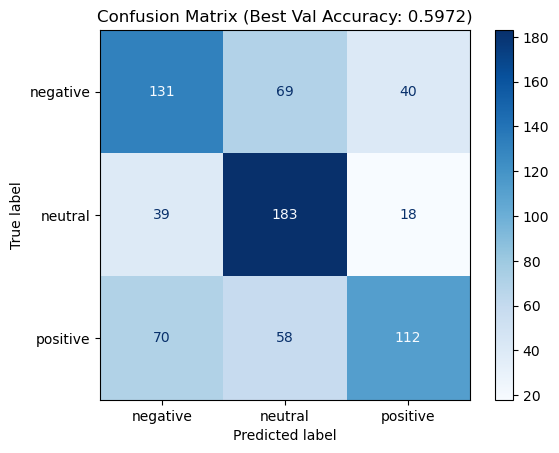

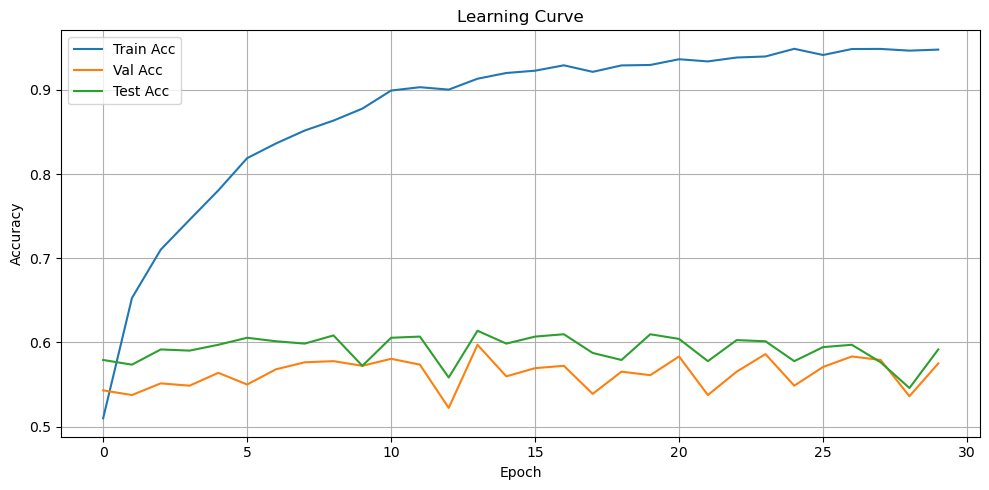

In [11]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/dynabench/train.csv"
val_file = "/Users/tejamallireddy/Downloads/dynabench/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/dynabench/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# ------------------- Preprocess -------------------
for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)
    df['untokenized_text'] = df['tokenized_text'].apply(lambda x: " ".join(x))

# ➕ TF-IDF (optional)
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(data_train['untokenized_text'])

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# ------------------- CNN Model -------------------
class CNN_Ngram(nn.Module):
    def __init__(self, vocab_size, embed_size, num_classes, filters=[2, 3, 4, 5], num_filters=400, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = False
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, num_filters, (fs, embed_size)),
                nn.ReLU(),
                nn.BatchNorm2d(num_filters)
            ) for fs in filters
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filters) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = [conv(x).squeeze(3) for conv in self.convs]
        x = [torch.max_pool1d(i, i.size(2)).squeeze(2) for i in x]
        x = torch.cat(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CNN_Ngram(len(vocab) + 1, 300, len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# yelp

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.4805, Val Acc: 0.5908, Test Acc: 0.6019
Epoch 2, Train Acc: 0.5585, Val Acc: 0.6131, Test Acc: 0.6169
Epoch 3, Train Acc: 0.5773, Val Acc: 0.6494, Test Acc: 0.6578
Epoch 4, Train Acc: 0.5985, Val Acc: 0.5856, Test Acc: 0.6047
Epoch 5, Train Acc: 0.6115, Val Acc: 0.6350, Test Acc: 0.6564
Epoch 6, Train Acc: 0.6214, Val Acc: 0.6483, Test Acc: 0.6531
Epoch 7, Train Acc: 0.6341, Val Acc: 0.6669, Test Acc: 0.6844
Epoch 8, Train Acc: 0.6431, Val Acc: 0.6536, Test Acc: 0.6525
Epoch 9, Train Acc: 0.6654, Val Acc: 0.6639, Test Acc: 0.6775
Epoch 10, Train Acc: 0.6647, Val Acc: 0.6664, Test Acc: 0.6736
Epoch 11, Train Acc: 0.6775, Val Acc: 0.6556, Test Acc: 0.6717
Epoch 12, Train Acc: 0.6906, Val Acc: 0.6586, Test Acc: 0.6711
Epoch 13, Train Acc: 0.7069, Val Acc: 0.6447, Test Acc: 0.6550
Epoch 14, Train Acc: 0.7144, Val Acc: 0.6414, Test Acc: 0.6583
Epoch 15, Train Acc: 0.7264, Val Acc: 0.6528, Test Acc: 0.6583
Epoch 16, Train Acc: 0.7383, Val Acc: 0.6583, Test Acc: 0.6672
E

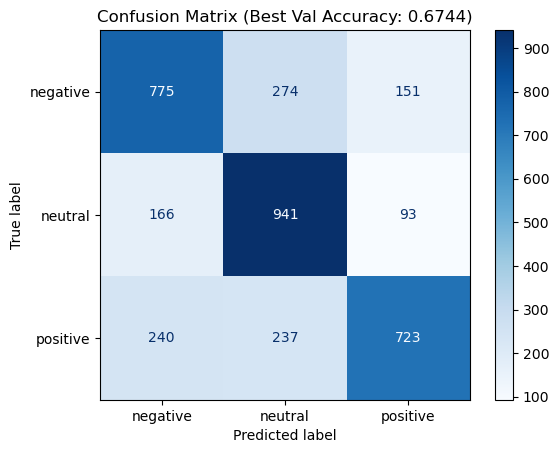

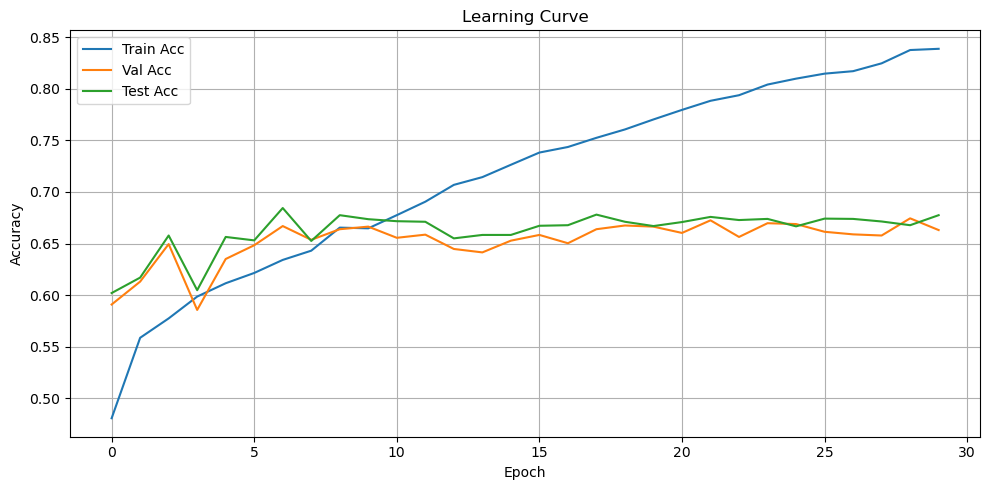

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# ------------------- Preprocess -------------------
for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)
    df['untokenized_text'] = df['tokenized_text'].apply(lambda x: " ".join(x))

# ➕ TF-IDF (optional)
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(data_train['untokenized_text'])

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# ------------------- CNN Model -------------------
class CNN_Ngram(nn.Module):
    def __init__(self, vocab_size, embed_size, num_classes, filters=[2, 3, 4, 5], num_filters=400, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = False
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, num_filters, (fs, embed_size)),
                nn.ReLU(),
                nn.BatchNorm2d(num_filters)
            ) for fs in filters
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filters) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = [conv(x).squeeze(3) for conv in self.convs]
        x = [torch.max_pool1d(i, i.size(2)).squeeze(2) for i in x]
        x = torch.cat(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CNN_Ngram(len(vocab) + 1, 300, len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)


# yelp_dynabench_2500

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/tejamallireddy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


Epoch 1, Train Acc: 0.4918, Val Acc: 0.5597, Test Acc: 0.5778
Epoch 2, Train Acc: 0.5667, Val Acc: 0.5715, Test Acc: 0.5708
Epoch 3, Train Acc: 0.5887, Val Acc: 0.5201, Test Acc: 0.5083
Epoch 4, Train Acc: 0.6072, Val Acc: 0.5625, Test Acc: 0.5840
Epoch 5, Train Acc: 0.6145, Val Acc: 0.5965, Test Acc: 0.5917
Epoch 6, Train Acc: 0.6275, Val Acc: 0.5833, Test Acc: 0.6014
Epoch 7, Train Acc: 0.6403, Val Acc: 0.5632, Test Acc: 0.5785
Epoch 8, Train Acc: 0.6451, Val Acc: 0.6007, Test Acc: 0.6208
Epoch 9, Train Acc: 0.6567, Val Acc: 0.6160, Test Acc: 0.6125
Epoch 10, Train Acc: 0.6671, Val Acc: 0.6201, Test Acc: 0.6174
Epoch 11, Train Acc: 0.6778, Val Acc: 0.6111, Test Acc: 0.6069
Epoch 12, Train Acc: 0.6798, Val Acc: 0.6132, Test Acc: 0.6208
Epoch 13, Train Acc: 0.6968, Val Acc: 0.6021, Test Acc: 0.6215
Epoch 14, Train Acc: 0.7063, Val Acc: 0.5965, Test Acc: 0.6215
Epoch 15, Train Acc: 0.7190, Val Acc: 0.6000, Test Acc: 0.6035
Epoch 16, Train Acc: 0.7283, Val Acc: 0.6014, Test Acc: 0.6181
E

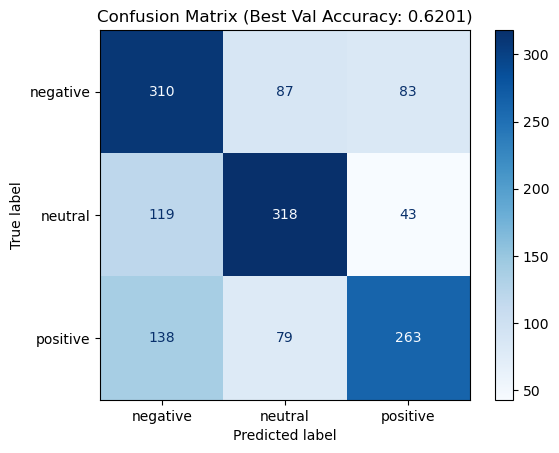

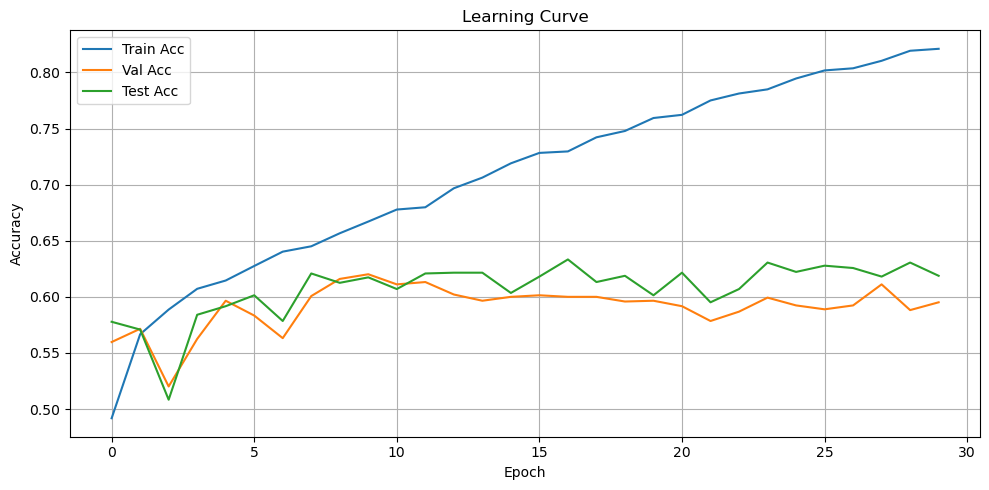

In [13]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import wordnet
from nltk import pos_tag
from nltk.stem import WordNetLemmatizer

# ------------------- NLTK Setup -------------------
for resource in ['punkt', 'wordnet', 'averaged_perceptron_tagger']:
    try:
        nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
    except LookupError:
        nltk.download(resource)

lemmatizer = WordNetLemmatizer()

def get_wordnet_pos(tag):
    if tag.startswith('J'): return wordnet.ADJ
    elif tag.startswith('V'): return wordnet.VERB
    elif tag.startswith('N'): return wordnet.NOUN
    elif tag.startswith('R'): return wordnet.ADV
    return wordnet.NOUN

def tokenize_text(text):
    tokens = word_tokenize(text.lower())
    return [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(tokens)]

# ------------------- Load Data -------------------
train_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/train.csv"
val_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/dev.csv"
test_file = "/Users/tejamallireddy/Downloads/yelp_dynabench_2500/test.csv"

def load_data(train_file, val_file, test_file):
    train_df = pd.read_csv(train_file)[['text', 'label']].dropna()
    val_df = pd.read_csv(val_file)[['text', 'label']].dropna()
    test_df = pd.read_csv(test_file)[['text', 'label']].dropna()
    return train_df, val_df, test_df

data_train, data_val, data_test = load_data(train_file, val_file, test_file)

# ------------------- Preprocess -------------------
for df in [data_train, data_val, data_test]:
    df['tokenized_text'] = df['text'].apply(tokenize_text)
    df['untokenized_text'] = df['tokenized_text'].apply(lambda x: " ".join(x))

# ➕ TF-IDF (optional)
vectorizer = TfidfVectorizer(max_features=5000)
vectorizer.fit(data_train['untokenized_text'])

# ------------------- Build Vocabulary -------------------
def build_vocab(texts):
    vocab = {}
    for text in texts:
        for word in text:
            if word not in vocab:
                vocab[word] = len(vocab) + 1
    return vocab

vocab = build_vocab(data_train['tokenized_text'])

# ------------------- GloVe Embeddings -------------------
def load_glove_embeddings(glove_path, vocab, embed_dim=300):
    embeddings = np.random.uniform(-0.25, 0.25, (len(vocab) + 1, embed_dim))
    with open(glove_path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            vector = np.array(parts[1:], dtype='float32')
            idx = vocab.get(word)
            if idx is not None:
                embeddings[idx] = vector
    return torch.tensor(embeddings, dtype=torch.float32)

glove_path = "/Users/tejamallireddy/Downloads/glove.6B.300d.txt"
pretrained_embeddings = load_glove_embeddings(glove_path, vocab)

# ------------------- Dataset & Loader -------------------
def text_to_indices(text, vocab, max_length=150):
    indices = [vocab.get(word, 0) for word in text[:max_length]]
    return indices + [0] * (max_length - len(indices))

le = LabelEncoder()
data_train['label'] = le.fit_transform(data_train['label'])
data_val['label'] = le.transform(data_val['label'])
data_test['label'] = le.transform(data_test['label'])

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab):
        self.texts = [torch.tensor(text_to_indices(t, vocab)) for t in texts]
        self.labels = torch.tensor(labels)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx): return self.texts[idx], self.labels[idx]

train_dataset = SentimentDataset(data_train['tokenized_text'], data_train['label'], vocab)
val_dataset = SentimentDataset(data_val['tokenized_text'], data_val['label'], vocab)
test_dataset = SentimentDataset(data_test['tokenized_text'], data_test['label'], vocab)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128)
test_loader = DataLoader(test_dataset, batch_size=128)

# ------------------- CNN Model -------------------
class CNN_Ngram(nn.Module):
    def __init__(self, vocab_size, embed_size, num_classes, filters=[2, 3, 4, 5], num_filters=400, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.embedding.weight.data.copy_(pretrained_embeddings)
        self.embedding.weight.requires_grad = False
        self.convs = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(1, num_filters, (fs, embed_size)),
                nn.ReLU(),
                nn.BatchNorm2d(num_filters)
            ) for fs in filters
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(len(filters) * num_filters, num_classes)

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)
        x = [conv(x).squeeze(3) for conv in self.convs]
        x = [torch.max_pool1d(i, i.size(2)).squeeze(2) for i in x]
        x = torch.cat(x, 1)
        x = self.dropout(x)
        return self.fc(x)

# ------------------- Training -------------------
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = CNN_Ngram(len(vocab) + 1, 300, len(le.classes_)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

def train_model(model, train_loader, val_loader, test_loader, epochs=30):
    train_acc_list, val_acc_list, test_acc_list = [], [], []
    best_val_acc = 0

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                val_correct += (preds == labels).sum().item()
                val_total += labels.size(0)
        val_acc = val_correct / val_total
        val_acc_list.append(val_acc)
        best_val_acc = max(best_val_acc, val_acc)

        # Test
        test_correct, test_total = 0, 0
        all_preds, all_labels = [], []
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                preds = torch.argmax(outputs, dim=1)
                test_correct += (preds == labels).sum().item()
                test_total += labels.size(0)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        test_acc = test_correct / test_total
        test_acc_list.append(test_acc)

        print(f"Epoch {epoch+1}, Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix (Best Val Accuracy: {best_val_acc:.4f})")
    plt.show()

    # Learning Curve
    plt.figure(figsize=(10, 5))
    plt.plot(train_acc_list, label="Train Acc")
    plt.plot(val_acc_list, label="Val Acc")
    plt.plot(test_acc_list, label="Test Acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ------------------- Run -------------------
train_model(model, train_loader, val_loader, test_loader)
